In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score,classification_report, ConfusionMatrixDisplay,confusion_matrix)
import time


Data Loading and Preprocessing for Classification

In [16]:
df = pd.read_csv('data/engineered_data.csv')
df.columns = df.columns.str.strip()

# Create the target variable based on the median number of shares
median_shares = df['shares'].median()
df['popular'] = (df['shares'] >= median_shares).astype(int)

# Define features and target
X = df.drop(columns=[ 'shares', 'popular','log_shares'])
y = df['popular']

# Split the dataset into training and testing sets
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42,stratify=y)

# Standardize the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset prepared successfully | Train: {X_train.shape} | Test: {X_test.shape}")

Dataset prepared successfully | Train: (30769, 68) | Test: (7693, 68)


Logistic Regression Hyperparameter Tuning using GridSearchCV

In [17]:
print("=" * 50)
print("1️  Logistic Regression Tuning")
print("=" * 50)

# The parameters we want to try
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],   # Regularization strength (larger C = less regularization)
    'penalty': ['l1', 'l2'],          # Type of regularization
    'solver': ['liblinear']           # Solver that supports both L1 and L2
}

# Using GridSearchCV because we have few parameters
start = time.time()

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,          # 5-fold cross validation
    scoring='f1',  # Optimize for F1 since classes are roughly balanced
    n_jobs=-1,     # Use all available CPU cores
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

elapsed = time.time() - start
print(f"\n Search time: {elapsed:.1f} seconds")
print(f"Best parameters: {grid_lr.best_params_}")
print(f" Best F1 (cross-val): {grid_lr.best_score_:.4f}")

# Evaluate on the test set
lr_best = grid_lr.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)
print(f" F1 on Test Set: {f1_score(y_test, y_pred_lr):.4f}")
print(f" AUC on Test Set: {roc_auc_score(y_test, lr_best.predict_proba(X_test_scaled)[:,1]):.4f}")

1️  Logistic Regression Tuning
Fitting 5 folds for each of 10 candidates, totalling 50 fits

 Search time: 35.4 seconds
Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
 Best F1 (cross-val): 0.6839
 F1 on Test Set: 0.6773
 AUC on Test Set: 0.7053


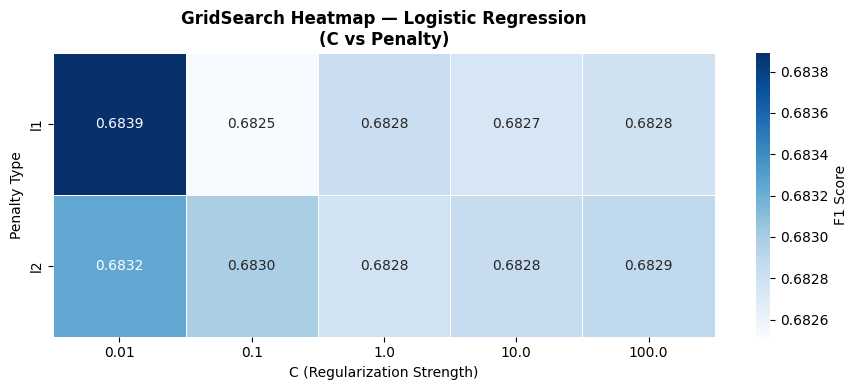

In [18]:
# Extract GridSearch results
results_lr = pd.DataFrame(grid_lr.cv_results_)

# Create pivot table for the heatmap
pivot = results_lr.pivot_table(
    values='mean_test_score',
    index='param_penalty',
    columns='param_C'
)

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'F1 Score'})
plt.title('GridSearch Heatmap — Logistic Regression\n(C vs Penalty)', fontweight='bold')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('Penalty Type')
plt.tight_layout()
plt.savefig('heatmap_lr.png', dpi=150)
plt.show()

In [19]:
print("=" * 50)
print("2️  Random Forest Tuning (RandomizedSearchCV)")
print("=" * 50)
# Random Forest has many parameters → RandomizedSearch is faster
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],       # number of trees
    'max_depth': [None, 5, 10, 20, 30],        # tree depth (None = unlimited)
    'min_samples_split': [2, 5, 10],           # min samples required to split a node
    'min_samples_leaf': [1, 2, 4],             # min samples required at a leaf
    'max_features': ['sqrt', 'log2']           # number of features per split
}
start = time.time()
random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist_rf,
    n_iter=30,           # try only 30 random combinations (not all)
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_rf.fit(X_train, y_train)
elapsed = time.time() - start

print(f" Best parameters: {random_rf.best_params_}")
print(f" Best F1 (cross-val): {random_rf.best_score_:.4f}")
rf_best = random_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print(f" F1 on Test Set: {f1_score(y_test, y_pred_rf):.4f}")

2️  Random Forest Tuning (RandomizedSearchCV)
Fitting 5 folds for each of 30 candidates, totalling 150 fits


 Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
 Best F1 (cross-val): 0.7032
 F1 on Test Set: 0.7011


In [20]:
print("=" * 50)
print("3  XGBoost Tuning (RandomizedSearchCV)")
print("=" * 50)

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # Learning rate
    'subsample': [0.7, 0.8, 1.0],               # Fraction of data per tree
    'colsample_bytree': [0.7, 0.8, 1.0],        # Fraction of features per tree
    'reg_alpha': [0, 0.1, 0.5],                 # L1 regularization
    'reg_lambda': [1, 1.5, 2]                   # L2 regularization
}

start = time.time()
random_xgb = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=42, verbosity=0),
    param_dist_xgb,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_xgb.fit(X_train, y_train)
elapsed = time.time() - start

print(f" Best parameters: {random_xgb.best_params_}")
print(f" Best F1 (cross-val): {random_xgb.best_score_:.4f}")

xgb_best = random_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
print(f" F1 on Test Set: {f1_score(y_test, y_pred_xgb):.4f}")

3  XGBoost Tuning (RandomizedSearchCV)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
 Best parameters: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
 Best F1 (cross-val): 0.7051
 F1 on Test Set: 0.7018


In [21]:
# KNN Tuning
print("4️  KNN Tuning")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],   # Number of neighbors
    'weights': ['uniform', 'distance'],       # uniform=equal weight, distance=closer neighbors matter more
    'metric': ['euclidean', 'manhattan']      # Distance calculation method
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5, scoring='f1', n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)
knn_best = grid_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)
print(f"   Best params: {grid_knn.best_params_}")
print(f"   F1 Test: {f1_score(y_test, y_pred_knn):.4f}\n")

# Decision Tree Tuning
print("5  Decision Tree Tuning")
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']       # gini is faster, entropy is sometimes more accurate
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train, y_train)
dt_best = grid_dt.best_estimator_
y_pred_dt = dt_best.predict(X_test)
print(f"   Best params: {grid_dt.best_params_}")
print(f"   F1 Test: {f1_score(y_test, y_pred_dt):.4f}")

4️  KNN Tuning
   Best params: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}
   F1 Test: 0.6564

5  Decision Tree Tuning
   Best params: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 2}
   F1 Test: 0.6639


 Final Results After Tuning:

                     Accuracy      F1     AUC
Model                                        
XGBoost                0.6646  0.7018  0.7245
Random Forest          0.6696  0.7011  0.7313
Logistic Regression    0.6483  0.6773  0.7053
Decision Tree          0.6467  0.6639  0.6907
KNN                    0.6398  0.6564  0.6942


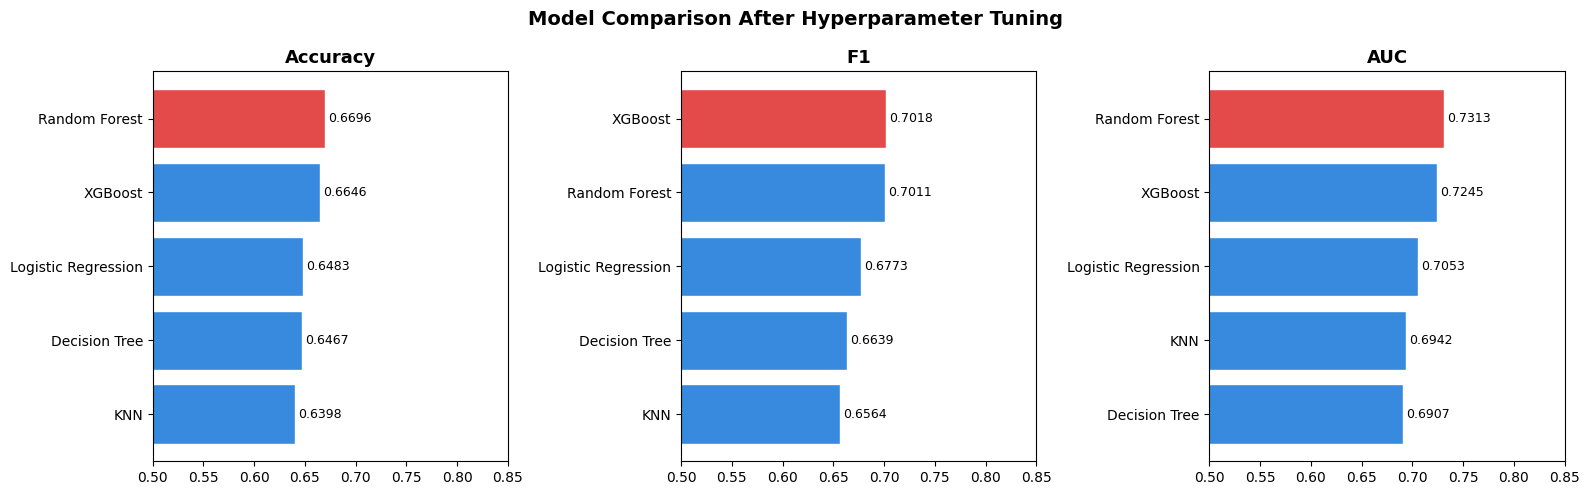


 Best Model After Tuning: XGBoost
   F1 = 0.7018


In [22]:
# Before and After Tuning
tuned_models = {
    'Logistic Regression': (lr_best,  X_test_scaled, y_pred_lr),
    'KNN':                 (knn_best, X_test_scaled, y_pred_knn),
    'Decision Tree':       (dt_best,  X_test,        y_pred_dt),
    'Random Forest':       (rf_best,  X_test,        y_pred_rf),
    'XGBoost':             (xgb_best, X_test,        y_pred_xgb),
}

print(" Final Results After Tuning:\n")

summary = []
for name, (model, X_ev, y_pred) in tuned_models.items():
    summary.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred),
        'AUC':      roc_auc_score(y_test,
                        model.predict_proba(X_ev)[:, 1])
    })

summary_df = pd.DataFrame(summary).sort_values('F1', ascending=False)
summary_df = summary_df.set_index('Model')
print(summary_df.round(4).to_string())

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    vals = summary_df[metric].sort_values()
    colors = ['#E24B4A' if v == vals.max() else '#378ADD' for v in vals]
    bars = ax.barh(vals.index, vals, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xlim(0.5, 0.85)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison After Hyperparameter Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_final_comparison.png', dpi=150)
plt.show()

best_final = summary_df['F1'].idxmax()
print(f"\n Best Model After Tuning: {best_final}")
print(f"   F1 = {summary_df.loc[best_final, 'F1']:.4f}")

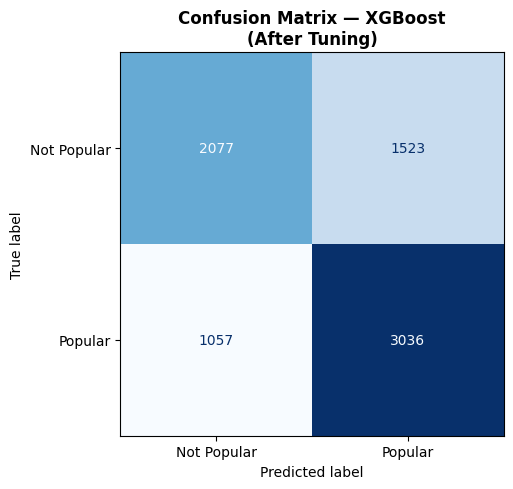


 Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.66      0.58      0.62      3600
     Popular       0.67      0.74      0.70      4093

    accuracy                           0.66      7693
   macro avg       0.66      0.66      0.66      7693
weighted avg       0.66      0.66      0.66      7693



In [23]:
best_model_obj = tuned_models[best_final][0]
best_X_ev      = tuned_models[best_final][1]
best_y_pred    = tuned_models[best_final][2]

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Popular', 'Popular'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_final}\n(After Tuning)', fontweight='bold')
plt.tight_layout()
plt.savefig('best_model_cm.png', dpi=150)
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, best_y_pred,
                            target_names=['Not Popular', 'Popular']))